# setup environment


In [ ]:
!pip install transformers
!pip install datasets

In [ ]:
from datasets import load_dataset

data_train_path = '/content/drive/MyDrive/TTCSDL/data_ch_1/train'
data_val_path = '/content/drive/MyDrive/TTCSDL/data_ch_1/val'

train_dataset = load_dataset("imagefolder", data_dir=data_train_path)
val_dataset = load_dataset("imagefolder", data_dir=data_val_path)

Resolving data files:   0%|          | 0/2202 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Resolving data files:   0%|          | 0/413 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
train_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2202
    })
})

In [ ]:
val_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 413
    })
})

0


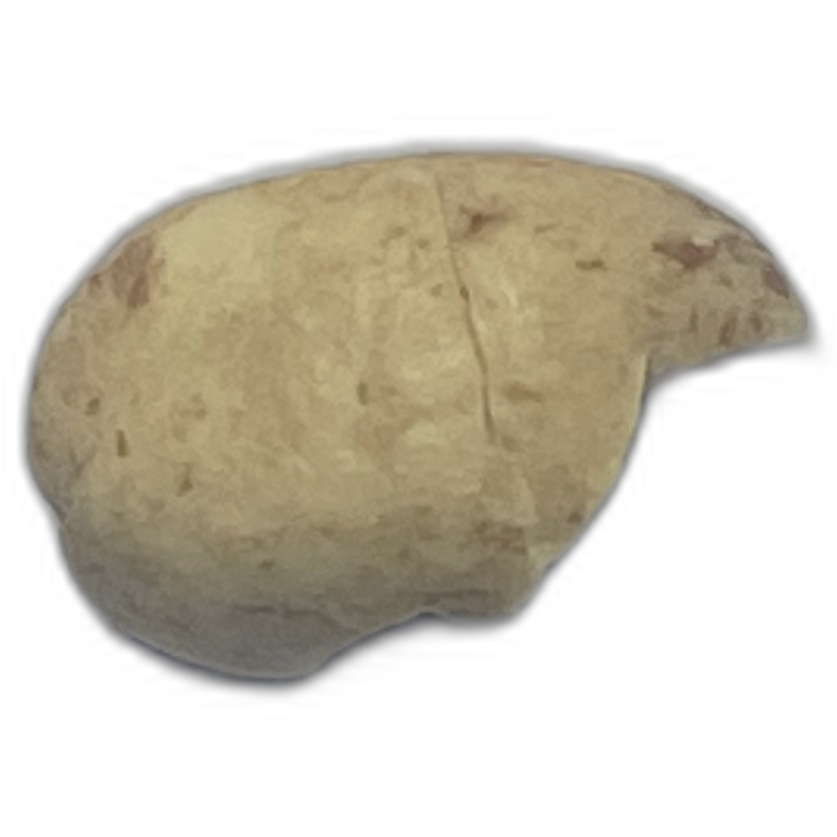

In [ ]:
example = train_dataset['train'][0]
print(example['label'])
example['image']

In [ ]:
train_dataset['train'].features['label'].names

['bad', 'good']

# 0 là bad , 1 là good


In [ ]:
from transformers import ConvNextImageProcessor, ConvNextForImageClassification
import torch
from datasets import load_dataset

processor = ConvNextImageProcessor.from_pretrained("facebook/convnext-tiny-224")
model = ConvNextForImageClassification.from_pretrained("facebook/convnext-tiny-224")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
processor

ConvNextImageProcessor {
  "crop_pct": 0.875,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

không dùng processor tạo transform convert ảnh vào thêm xoay ngẫu nhiên, và một số phương pháp đổ bóng, ... để tăng dataset cho tập train vì dataset khá ít

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(360),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean,
                         std=processor.image_std)
])

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=data_train_path,
    transform=train_transform
)
val_dataset = datasets.ImageFolder(
    root=data_val_path,
    transform=train_transform
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)  # (32, 3, 224, 224)
print(labels)

torch.Size([32, 3, 224, 224])
tensor([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1])


In [ ]:
num_class = 2
model.classifier = torch.nn.Linear(
    model.classifier.in_features,
    num_class
)

In [ ]:
for param in model.convnext.parameters():
    param.requires_grad = False

In [ ]:
device = "cuda"
model.to(device)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)
        loss = criterion(outputs.logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if epoch == 4:
        print("Unfreezing backbone...")
        for param in model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=1e-5
        )

Epoch 1, Loss: 44.4650
Epoch 2, Loss: 36.8654
Epoch 3, Loss: 32.0331
Epoch 4, Loss: 29.0587
Epoch 5, Loss: 26.8699
Unfreezing backbone...
Epoch 6, Loss: 20.9979
Epoch 7, Loss: 17.8163
Epoch 8, Loss: 16.4894
Epoch 9, Loss: 15.8285
Epoch 10, Loss: 15.6211


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)
        preds = outputs.logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Val Acc:", correct / total)

Val Acc: 0.9878934624697336


In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import f1_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

f1 = f1_score(all_labels, all_preds, average='macro')

print("F1-score:", f1)

F1-score: 0.9951471141191953


In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/convnext_coffee.pth")